# exploring symbiont communities in individual colonies overtime

## questions:
- are the symbiont communities changing during times of bleaching?
how about during disease outbreak?

In [1]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

Loading required package: data.table

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second(

### ps cleanup
- remove Diseased_margin
- remove taxa that never show up
- normalize

In [2]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/ps_all_ITS2.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 417 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 25 sample variables ]
tax_table()   Taxonomy Table:    [ 417 taxa by 8 taxonomic ranks ]

In [3]:
## remove samples with zero reads


In [4]:
## removing diseased_margin from ps_col

#new dataframes for each species 
ps_nomargin <- subset_samples(ps, Health_status != "Diseased_Margin")

#how many samples did I remove?
ps_nomargin

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 417 taxa and 446 samples ]
sample_data() Sample Data:       [ 446 samples by 25 sample variables ]
tax_table()   Taxonomy Table:    [ 417 taxa by 8 taxonomic ranks ]

In [5]:
ps_prune <- prune_taxa(taxa_sums(ps_nomargin) > 0, ps_nomargin)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 406 taxa and 446 samples ]
sample_data() Sample Data:       [ 446 samples by 25 sample variables ]
tax_table()   Taxonomy Table:    [ 406 taxa by 8 taxonomic ranks ]

In [6]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_prune, function(x) 1E6 * x / sum(x))

### clean up sample data
- convert ps object to df using vegan
- isolate only colonies that were sampled multiple times
- order the colonies by if they ever had diseased/ were ever bleached


In [7]:
pssd2veg <- function(ps_norm) {
  sd_nomit <- sample_data(ps_norm)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_norm)

sample_nomit <- as.data.frame(sample_data(ps_norm))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

In [8]:
# Return names which have more than one row of data
# Now filter
colonies <- sample_nomit %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#difference bw og and repeated colonies df
nrow(sample_nomit)
nrow(colonies)

[1] 446

[1] 429

In [9]:
#how many colonies are represented?
length(unique(colonies$colony))
head(colonies)

[1] 63

Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted,SampleID
<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>,<chr>
2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,2024-01-10,012024_BEL_CBC_T1_557_SSID
2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_559_MCAV
2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10,012024_BEL_CBC_T1_561_OANN
2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,2024-01-10,012024_BEL_CBC_T1_563_PSTR
2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8,2024-01-10,012024_BEL_CBC_T1_565_PAST
2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12,012024_BEL_CBC_T2_585_OFAV


#### clean colonies df up

In [10]:
colonies <- as.data.frame(colonies)
class(colonies)

Warning message in class(x) <- tibble_class:
“Setting class(x) to multiple strings ("tbl_df", "tbl", ...); result will no longer be an S4 object”


[1] "data.frame"

In [11]:
# Restore rownames
rownames(colonies) <- colonies$SampleID
#check
head(rownames(colonies))
nrow(sample_data(ps_norm))

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

[1] 446

In [12]:
head(colonies)

,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted,SampleID
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>,<chr>
012024_BEL_CBC_T1_557_SSID,2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,2024-01-10,012024_BEL_CBC_T1_557_SSID
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10,012024_BEL_CBC_T1_559_MCAV
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10,012024_BEL_CBC_T1_561_OANN
012024_BEL_CBC_T1_563_PSTR,2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,UML_NARWHAL_R5_B18,⋯,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,2024-01-10,012024_BEL_CBC_T1_563_PSTR
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8,2024-01-10,012024_BEL_CBC_T1_565_PAST
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12,012024_BEL_CBC_T2_585_OFAV


#### order by ever diseased/bleached and colonies that were only ever paled (never experienced full bleaching)

In [13]:
## how many colonies only ever experienced paling?
paling_only_count <- colonies %>%
  group_by(colony) %>%
  summarize(
    ever_paled = any(Condition == "CLP"),
    ever_fully_bleached = any(Condition %in% c("CLP,CLB", "CLB"))
  ) %>%
  # Filter for colonies that paled, but NEVER fully bleached
  filter(ever_paled == TRUE & ever_fully_bleached == FALSE) %>% 
  nrow()

print(paling_only_count)

[1] 14


In [14]:
#group by colony
colony_history <- colonies %>%
  group_by(colony) %>%
  summarize(
    # ever_diseased means that the colony was diagnosed with SCTLD
    ever_diseased = any(Condition == "Diseased"),
    
    # ever_bleached strictly means it hit full bleaching (CLB or CLP,CLB)
    ever_bleached = any(grepl("CLB", Condition)),
    
    # only_paled means it had CLP, but NEVER progressed to having CLB
    only_paled    = any(grepl("CLP", Condition)) & !ever_bleached
  )

# The rest of your labeling and arranging code works exactly the same:
colony_order_df <- colony_history %>%
  arrange(desc(ever_diseased), desc(ever_bleached), desc(only_paled), colony) %>%
  mutate(colony_label = case_when(
    ever_diseased == TRUE ~ paste(colony, "(Diseased)"),
    ever_bleached == TRUE ~ paste(colony, "(Bleached)"),
    only_paled    == TRUE ~ paste(colony, "(Paled Only)"),
    TRUE                  ~ as.character(colony)
  ))

In [15]:
# 3. Extract your vectors
ordered_colonies <- colony_order_df$colony
ordered_labels   <- colony_order_df$colony_label

### bring cleaned sample data into a new ps object
- ps_col

In [16]:
keep_samples <- rownames(colonies)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm
sum(keep_samples %in% sample_names(ps_norm))  # Should be 421

[1] 429

[1] 429

In [17]:
head(sample_names(ps_norm))
head(keep_samples)

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

[1] "012024_BEL_CBC_T1_557_SSID" "012024_BEL_CBC_T1_559_MCAV"
[3] "012024_BEL_CBC_T1_561_OANN" "012024_BEL_CBC_T1_563_PSTR"
[5] "012024_BEL_CBC_T1_565_PAST" "012024_BEL_CBC_T2_585_OFAV"

In [18]:
# Prune to keep only those samples
ps_col <- prune_samples(sample_names(ps_norm) %in% keep_samples, ps_norm)
     

In [19]:
## check up on ps_col
class(ps_col)
all(rownames(colonies) %in% sample_names(ps_col))
ps_col

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] TRUE

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 406 taxa and 429 samples ]
sample_data() Sample Data:       [ 429 samples by 25 sample variables ]
tax_table()   Taxonomy Table:    [ 406 taxa by 8 taxonomic ranks ]

In [20]:
#checking on ps_col
nrow(sample_data(ps_col))
head(sample_data(ps_col))

[1] 429

,Date_Extracted,Raw_ng_ul,Date_Enriched,Microbe_Location,Month_year,colony,CollectionDate,Species,Health_status,Sample_physical_location,⋯,Seq_run,Transect,sample_uid,data_set_uid,host_family,host_genus,host_species,collection_date,collection_depth,DateFormatted
,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<fct>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<date>
012024_BEL_CBC_T1_557_SSID,2_17_2025,44.6,,,Jan 2024,1_3,1/10/24,SSID,Healthy,UML_NARWHAL_R5_B18,⋯,1,CBC30N,262771,1416,Rhizangiidae,Siderastrea,sidera,202401,8,2024-01-10
012024_BEL_CBC_T1_559_MCAV,2_17_2025,14.8,,,Jan 2024,1_24,1/10/24,MCAV,Healthy,UML_NARWHAL_R5_B18,⋯,2,CBC30N,267721,1458,Montastraeidae,Montastrea,cavernosa,20240110,8,2024-01-10
012024_BEL_CBC_T1_561_OANN,2_17_2025,18,,,Jan 2024,1_25,1/10/24,OANN,Healthy,UML_NARWHAL_R5_B18,⋯,3,CBC30N,267626,1457,Merulinidae,Orbicella,annularis,20240110,8,2024-01-10
012024_BEL_CBC_T1_563_PSTR,2_17_2025,35.8,,,Jan 2024,1_12,1/10/24,PSTR,Healthy,UML_NARWHAL_R5_B18,⋯,1,CBC30N,262772,1416,Faviidae,Pseudodiploria,strigosa,202401,8,2024-01-10
012024_BEL_CBC_T1_565_PAST,2_17_2025,7.72,,,Jan 2024,1_21,1/10/24,PAST,Bleached_Tissue,UML_NARWHAL_R5_B18,⋯,4,CBC30N,269104,1471,Poritidae,Porites,asteroides,20240110,8,2024-01-10
012024_BEL_CBC_T2_585_OFAV,2_17_2025,71.6,,,Jan 2024,2_76,1/12/24,OFAV,Healthy,UML_NARWHAL_R5_B18,⋯,4,SR30N,269105,1471,Merulinidae,Orbicella,faveolata,20240112,8,2024-01-12


### clean up ps_col
- dates in chronological order
- new column named colony_labeled to use for diseased/bleached facets

In [21]:
unique(colonies$Month_year)

[1] Jan 2024 Feb 2024 Apr 2024 May 2022 Jun 2019 Jun 2024 Aug 2024 Sep 2023
 [9] Oct 2019 Nov 2023 Dec 2022 Dec 2023
12 Levels: Jan 2024 Feb 2024 Apr 2024 May 2022 Jun 2019 Jun 2024 ... Dec 2023

In [22]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_col)$Month_year <- factor(sample_data(ps_col)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))

In [23]:
# adding diseased vs bleached labels to facets

#create new col colony_labeled 

current_colonies <- sample_data(ps_col)$colony

# Create a column in sample_data(ps_col) where the disease, CLB, CLp VALUES are the labels, but the LEVELS dictate the order
sample_data(ps_col)$colony_labeled <- factor(
  colony_order_df$colony_label[match(current_colonies, colony_order_df$colony)],
  levels = ordered_labels
)

## how are the symbiont communities changing in individual corals overtime through stressors?

### taxa
#### clades

In [24]:
# confirm that singleton is removed
table(tax_table(ps_col)[, "Clade"])


  A   B   C   D   G 
132 132 108  30   4 

In [25]:
    # how many unique family taxa are there? 
length(unique(tax_table(ps_col)[, "Clade"])) # should be 5

rank_names(ps_col)

#check if clade is a factor
class(tax_table(ps_col)[, "Clade"])

[1] 5

[1] "Clade"                                            
[2] "Majority.ITS2.sequence"                           
[3] "Associated.species"                               
[4] "ITS2.profile.abundance.local"                     
[5] "ITS2.profile.abundance.DB"                        
[6] "ITS2.type.profile"                                
[7] "Sequence.accession...SymPortal.UID"               
[8] "Average.defining.sequence.proportions.and..stdev."

[1] "taxonomyTable"
attr(,"package")
[1] "phyloseq"

### plotting

In [26]:
options(repr.plot.width=20, repr.plot.height=15)

#### assigning clade colors 

In [27]:
clade <- unique(tax_table(ps_col)[, "Clade"])

base_palette <- colorRampPalette(brewer.pal(9, "Set1"))(9)

cladecolors <- sample(base_palette, length(clade))
cladecolors <- setNames(cladecolors, clade)

## overall clade plot

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 1218 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1218 rows containing missing values or values outside the scale range
(`geom_bar()`).”


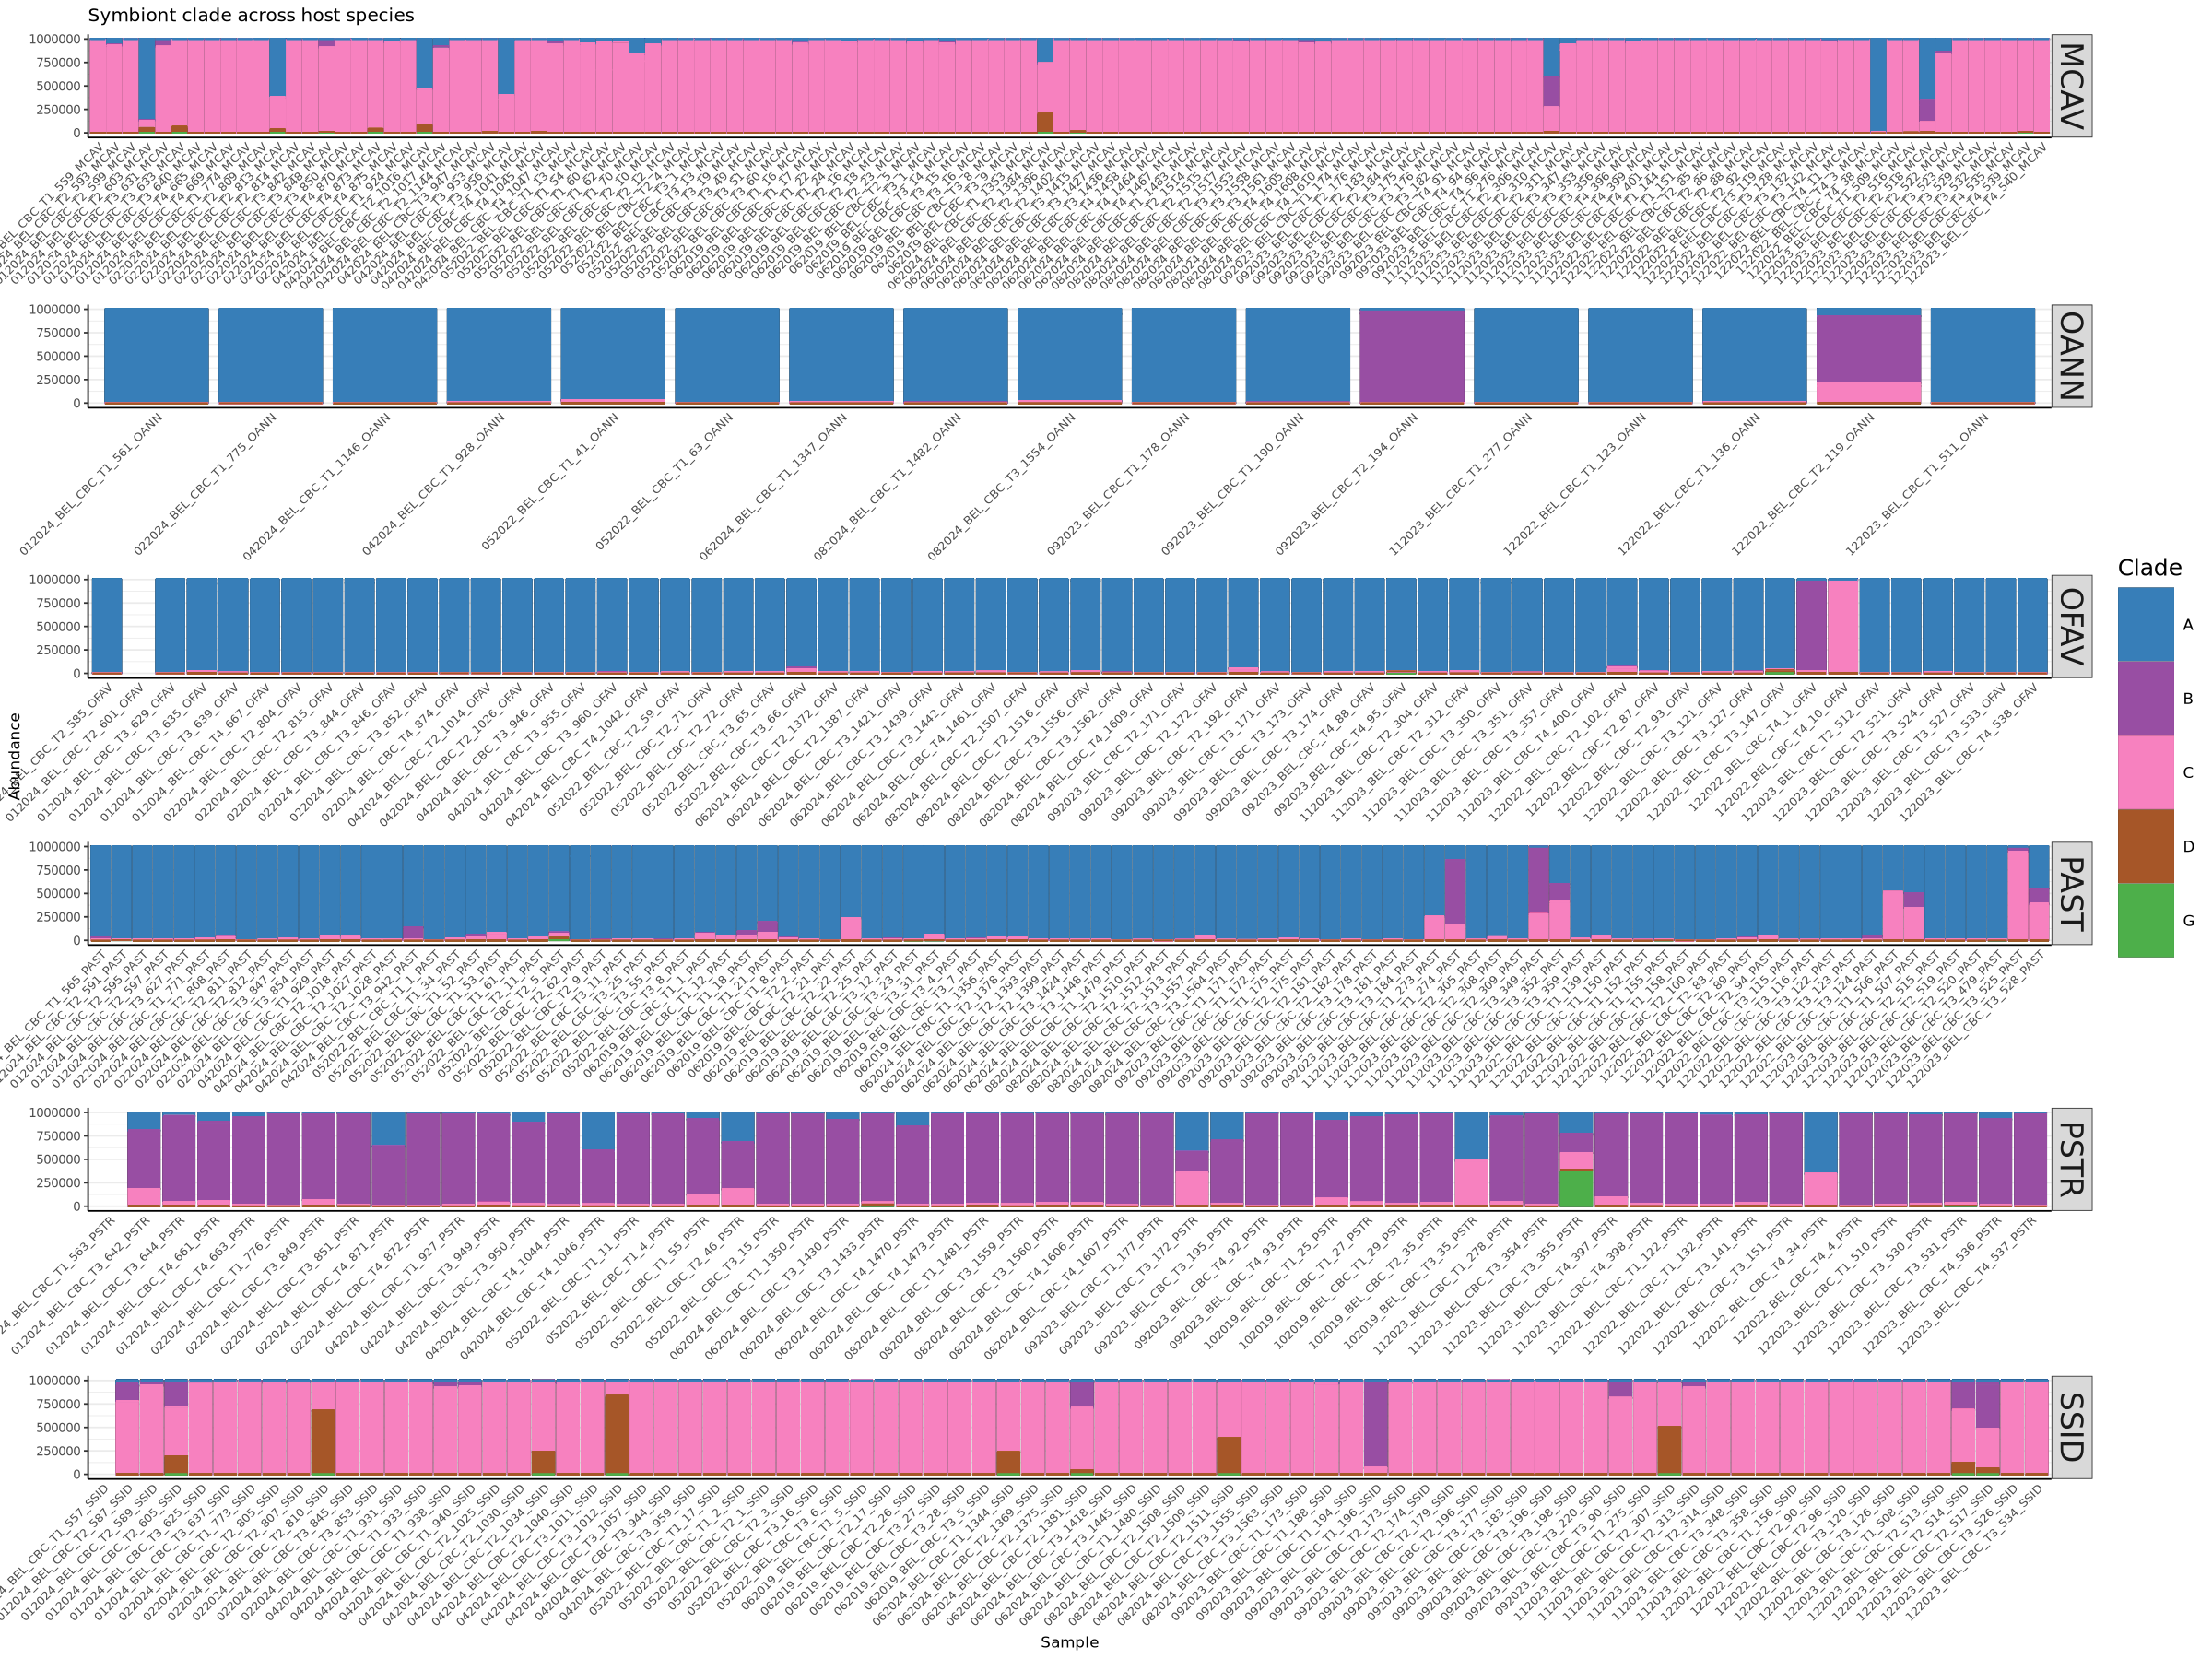

In [28]:
clade_plot <- plot_bar(ps_col, fill = "Clade") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free") + # Set desired font size
  geom_bar(aes(color = Clade, fill = Clade), 
           stat = "identity", position = "stack") +
  labs(title = "Symbiont clade across host species",
       x = "Sample",
       y = "Abundance",
       color = "Clade") +
  scale_fill_manual(values = cladecolors, drop = TRUE) +
  scale_color_manual(values = cladecolors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 20), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size =10)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
clade_plot

## overall its2 profile plot

#### its2 profile prep

In [29]:
    # how many unique family taxa are there?
length(unique(tax_table(ps_col)[, "ITS2.type.profile"]))

[1] 257

In [30]:
# Extract ITS2 profiles and clades directly from phyloseq object
its2 <- psmelt(ps_col)

profiles <- unique(as.character(its2$Majority.ITS2.sequence))
profiles <- trimws(profiles)
profiles <- profiles[!is.na(profiles)]

# Extract clade letter from each profile (e.g., "A3" -> "A")
clade <- substr(profiles, 1, 1)

#### assigning its2 profile colors based on clade 

In [31]:
#shift base color toward white
lighten_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  lighter <- rgb_col + (1 - rgb_col) * factor
  rgb(lighter[1], lighter[2], lighter[3])
}

In [32]:
#shift base color towards black
darken_color <- function(col, factor = 0.7) {
  rgb_col <- col2rgb(col) / 255
  darker <- rgb_col * (1 - factor)
  rgb(darker[1], darker[2], darker[3])
}

In [33]:
profile_colors <- list()

for (cl in unique(clade)) {

  cl_profiles <- profiles[clade == cl]
  n <- length(cl_profiles)

  if (n > 0) {

    base_col <- cladecolors[[cl]]
    light_col <- lighten_color(base_col, 0.5)
    dark_col <- darken_color(base_col, 0.5) 

    ramp <- colorRampPalette(c(light_col, base_col, dark_col))(n)

    profile_colors[[cl]] <- setNames(ramp, cl_profiles)
  }
}

profile_colors <- unlist(profile_colors)

In [34]:
### figure out what this does again
names(profile_colors) <- sub("^[A-Z]\\.", "", names(profile_colors))

In [35]:
# inspect plotting issues 
## these should be the same at this point and they are not 
unique(its2$Majority.ITS2.sequence)[1:20]
head(names(profile_colors), 20)

[1] "A3"        "A3/A4"     "A4a"       "C3"        "C1"        "A4"       
 [7] "C3cd/C3"   "A4a/A4"    "C21/C3"    "A3/A4a"    "C21"       "A3/A4/A4a"
[13] "B1"        "A4/A3/A4a" "A4/A4a"    "C1/C3"     "B1/B14d"   "B1/B1be"  
[19] "B14d/B1"   "B14d"

[1] "A3"            "A3/A4"         "A4a"           "A4"           
 [5] "A4a/A4"        "A3/A4a"        "A3/A4/A4a"     "A4/A3/A4a"    
 [9] "A4/A4a"        "A4/A3"         "A13"           "A3/A4/A13/A4a"
[13] "A3/A4/A13"     "A3/A13"        "A4z"           "A3/A4a/A13"   
[17] "A3bb/A3bt"     "A3bb"          "A1pp"          "C3"

<Guides[1] ggproto object>

colour : <GuideLegend>

Ignoring unknown labels:
• colour : "Majority.ITS2.sequence"
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“Removed 1218 rows containing missing values or values outside the scale range
(`geom_bar()`).”


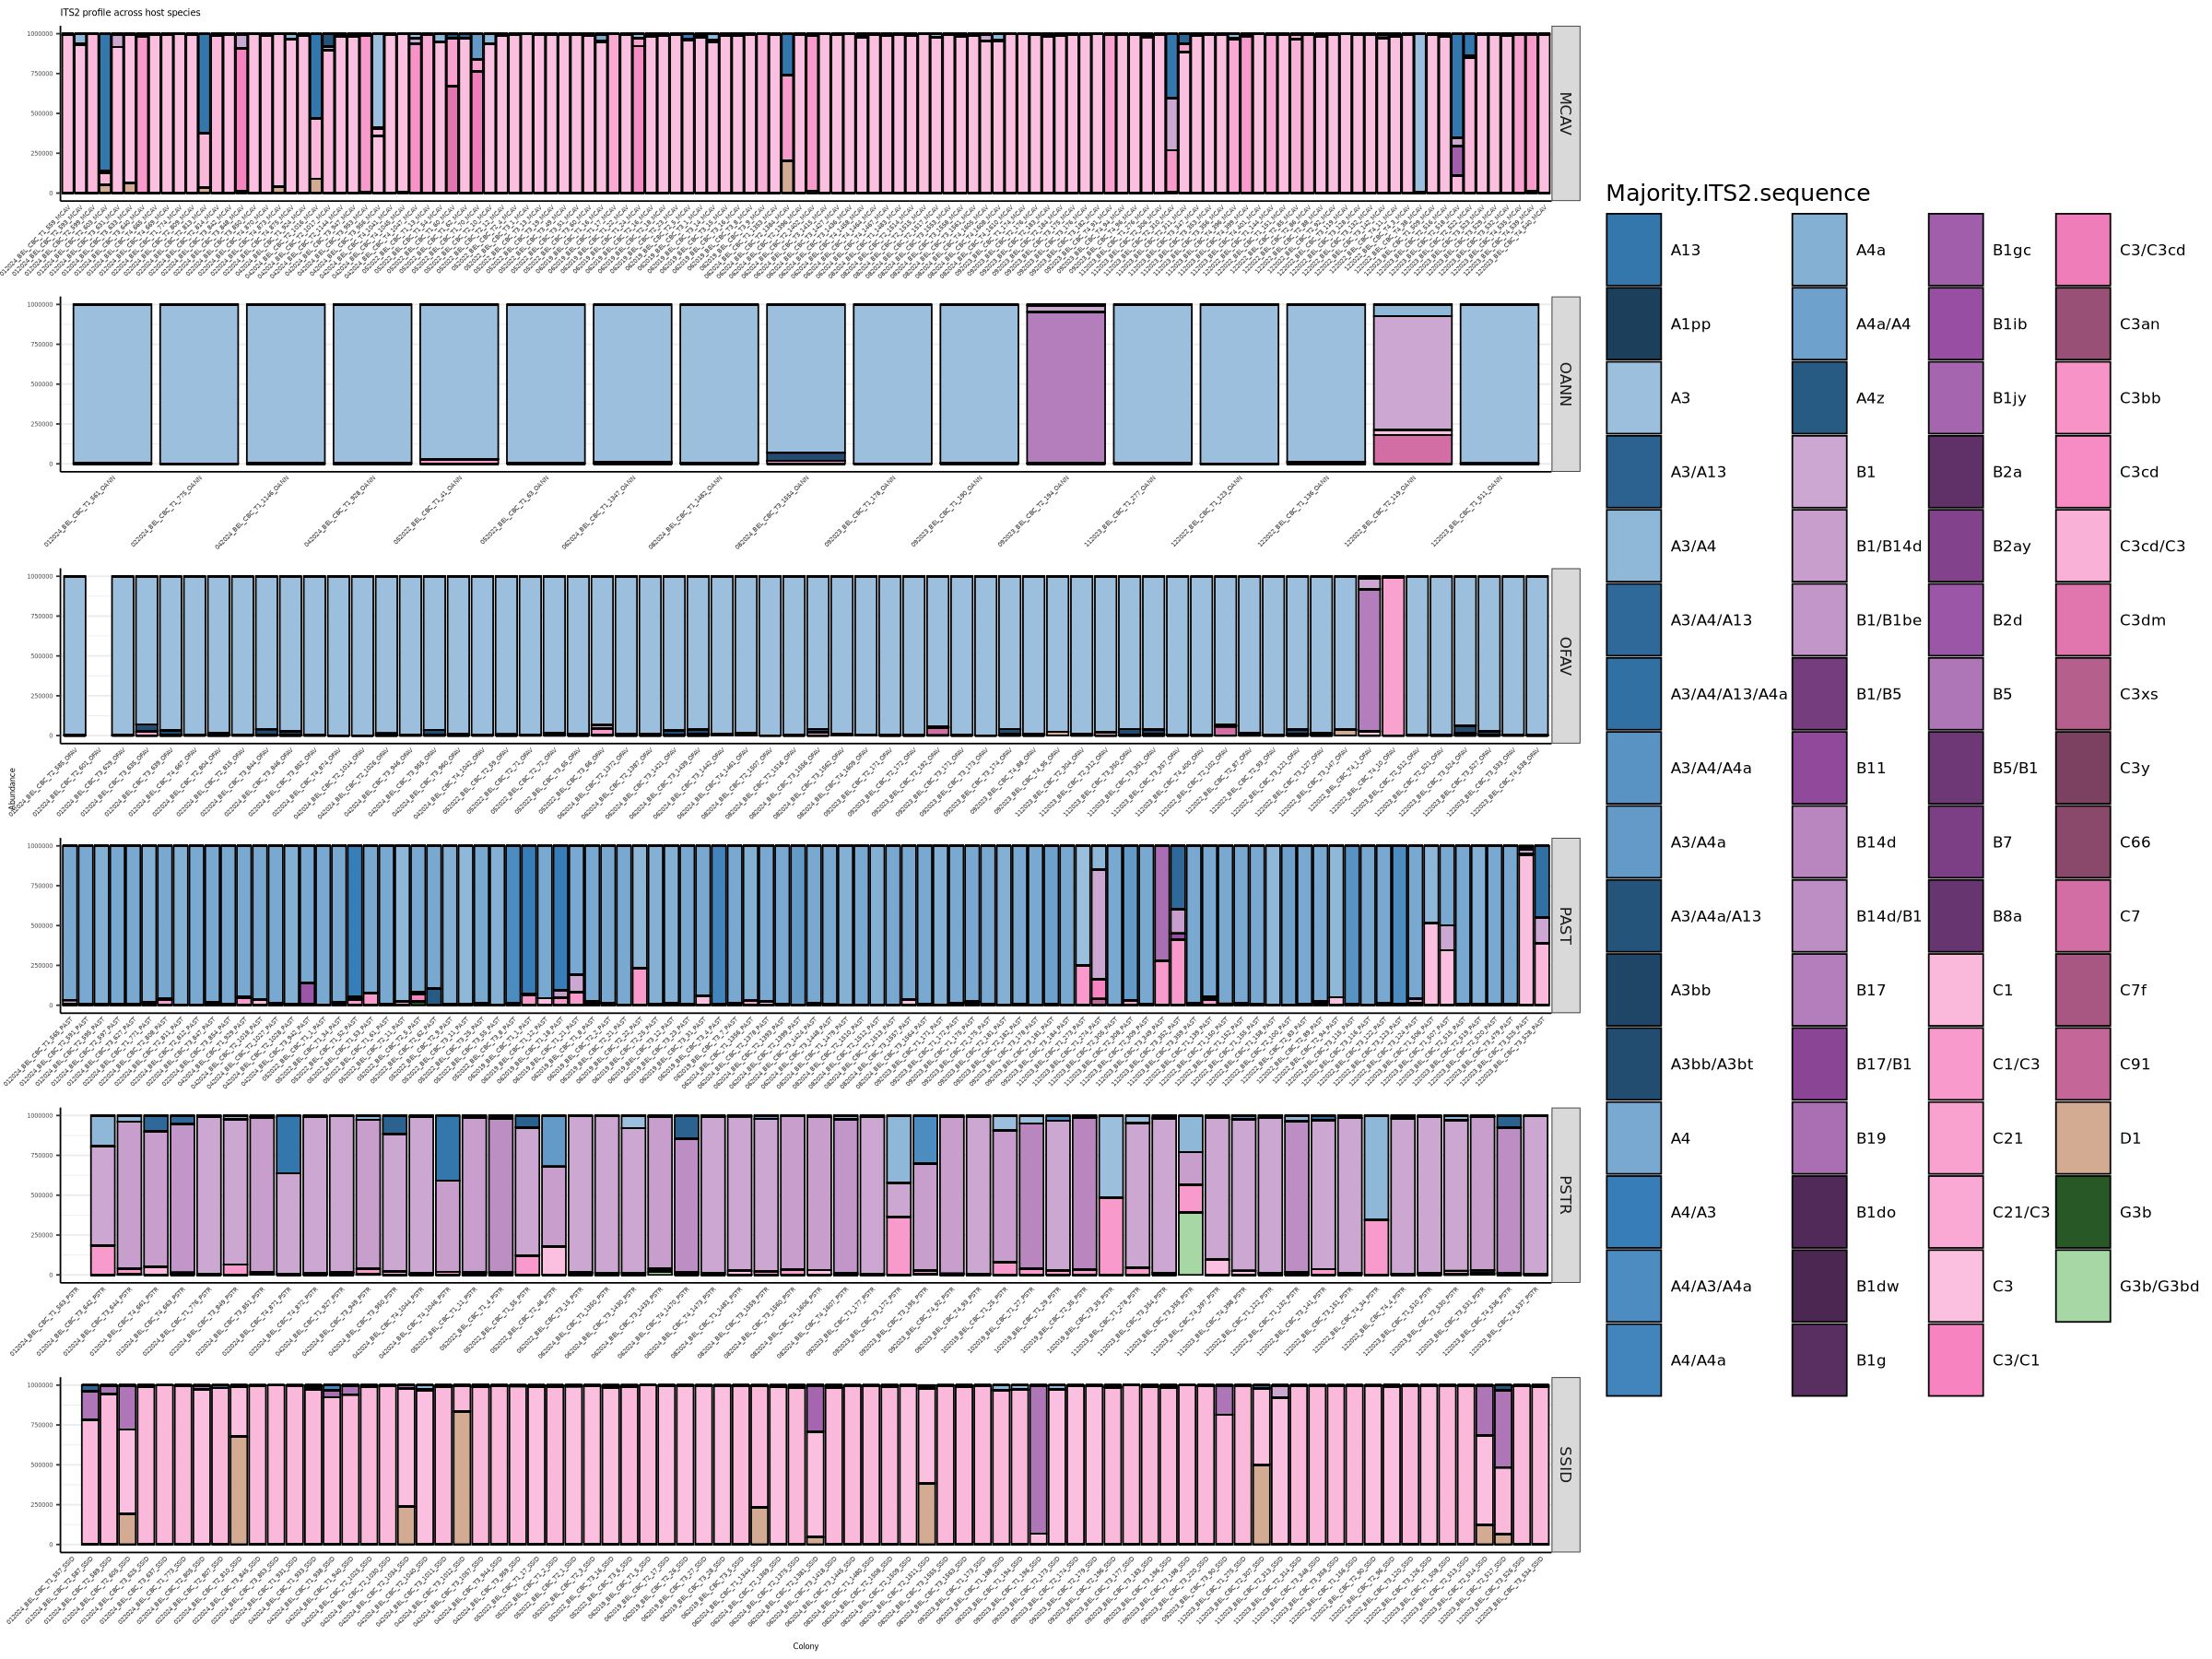

In [36]:
sam_profile <- plot_bar(ps_col, fill = "Majority.ITS2.sequence") +
facet_wrap(Species ~., strip.position = "right",  ncol = 1, scales = "free_x") + # Set desired font size
  labs(title = "ITS2 profile across host species",
       x = "Colony",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(strip.text = element_text(size = 10), #facet text size
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 5)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
sam_profile

## each species gets its out time series plot

In [37]:
#new dataframes for each species 
ps_mcav <- subset_samples(ps_col, Species == "MCAV")
ps_pstr <- subset_samples(ps_col, Species == "PSTR")
ps_ofav <- subset_samples(ps_col, Species == "OFAV")
ps_ssid <- subset_samples(ps_col, Species == "SSID")
ps_oann <- subset_samples(ps_col, Species == "OANN")
ps_past <- subset_samples(ps_col, Species == "PAST") 

## past

<Guides[1] ggproto object>

colour : <GuideLegend>

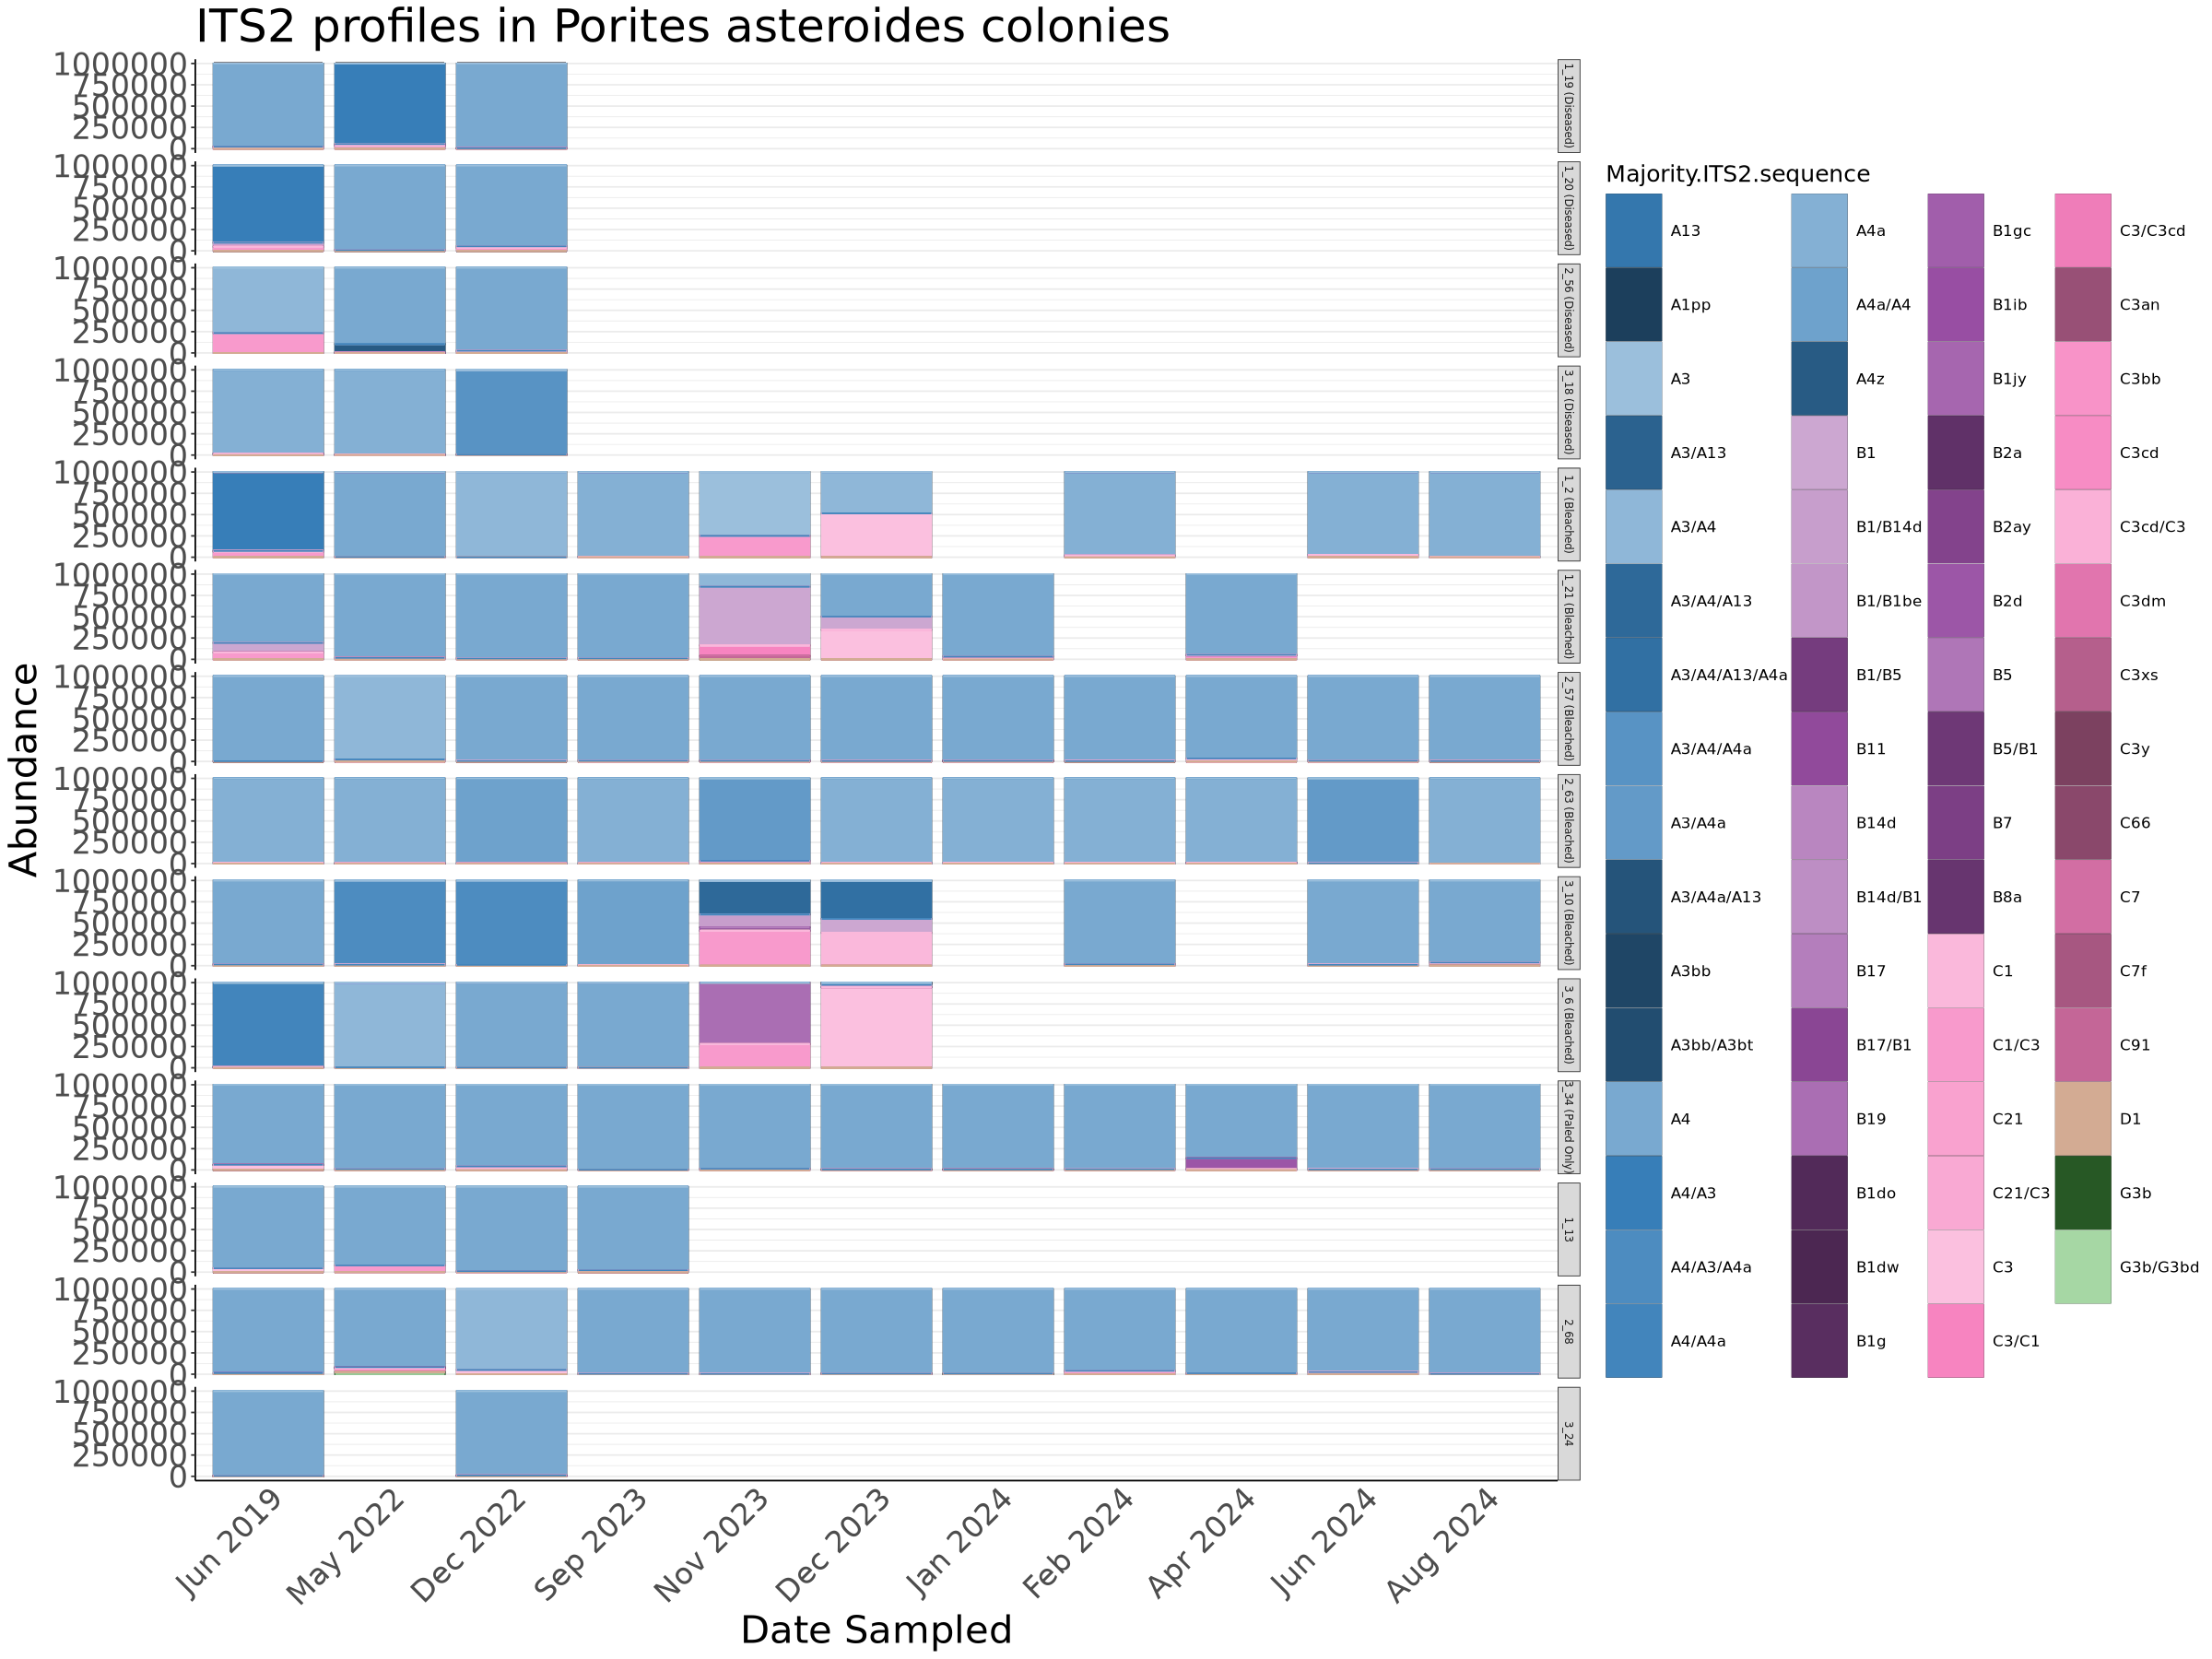

In [38]:
past= plot_bar(ps_past, x= "Month_year", fill = "Majority.ITS2.sequence") +
facet_wrap(colony_labeled ~., strip.position = "right",  ncol = 1) + # Set desired font size
geom_bar(aes(color = Majority.ITS2.sequence, fill = Majority.ITS2.sequence), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Porites asteroides colonies",
       x = "Date Sampled",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25),
           strip.text = element_text(size = 7) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 20))) 
past

## pstr

<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 406 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 406 rows containing missing values or values outside the scale range
(`geom_bar()`).”


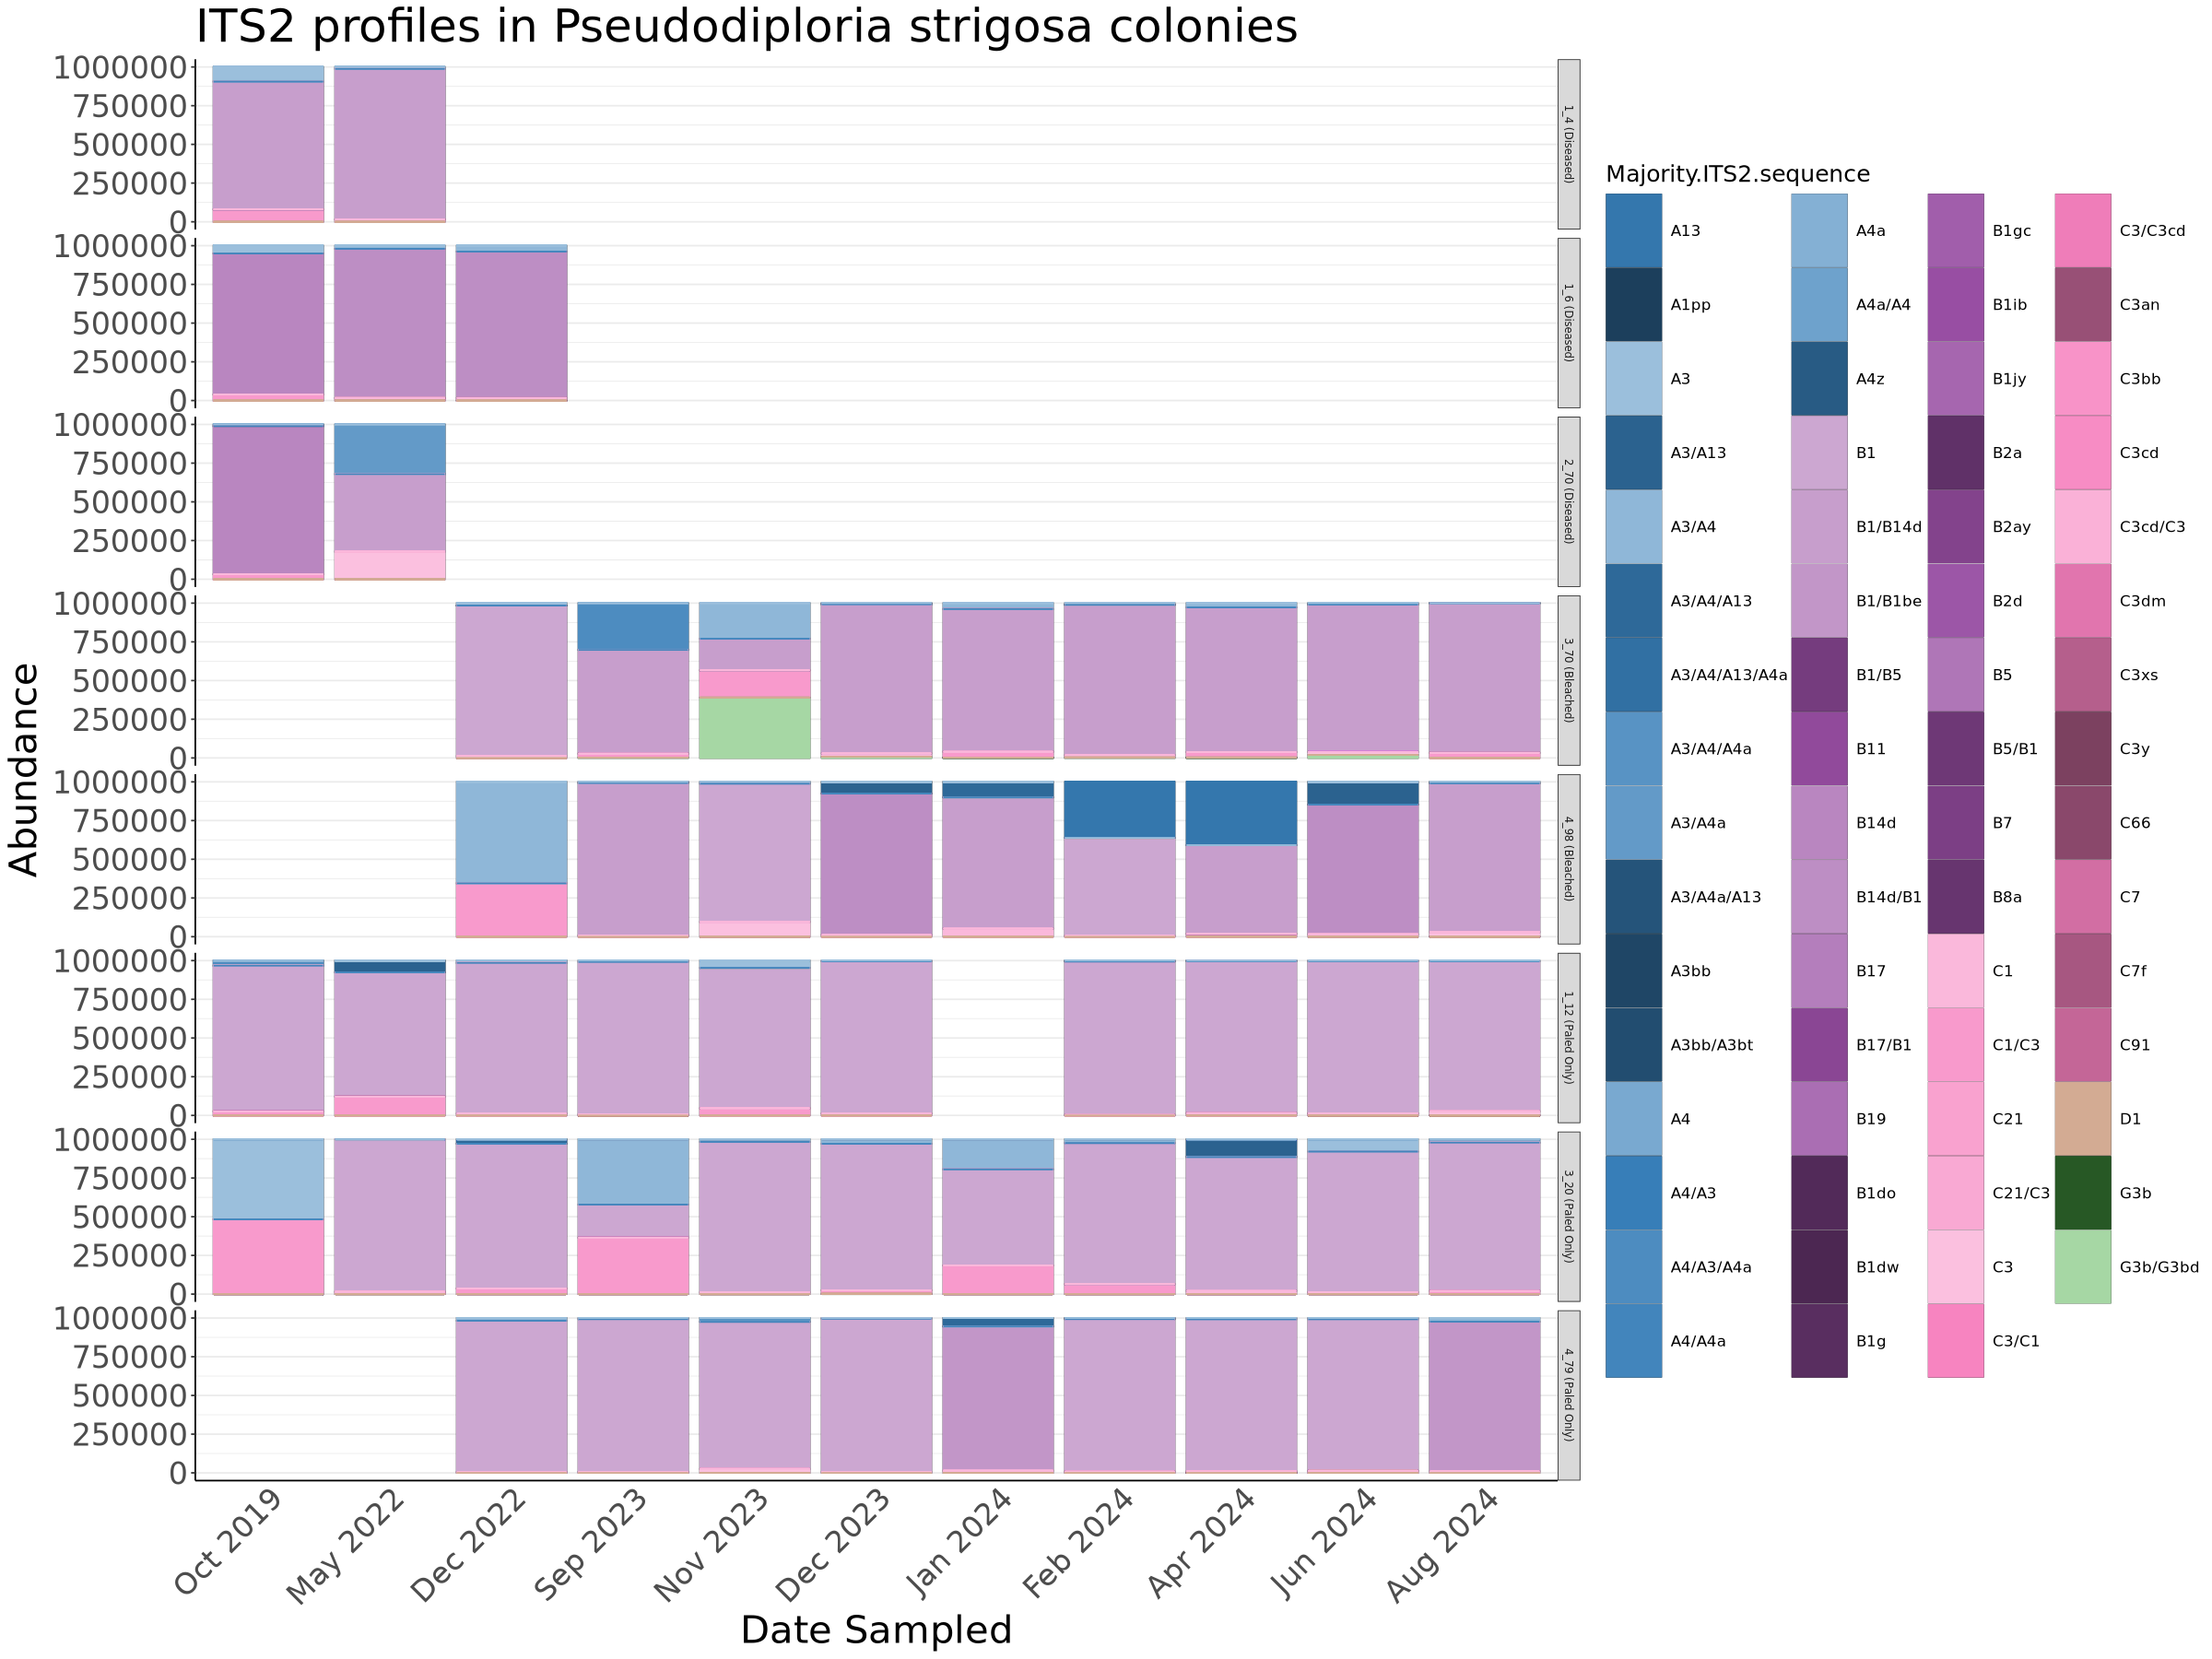

In [39]:
pstr= plot_bar(ps_pstr, x= "Month_year", fill = "Majority.ITS2.sequence") +
facet_wrap(colony_labeled ~., strip.position = "right",  ncol = 1) + # Set desired font size
geom_bar(aes(color = Majority.ITS2.sequence, fill = Majority.ITS2.sequence), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Pseudodiploria strigosa colonies",
       x = "Date Sampled",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25),
           strip.text = element_text(size = 7) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 20))) 
pstr

## mcav

<Guides[1] ggproto object>

colour : <GuideLegend>

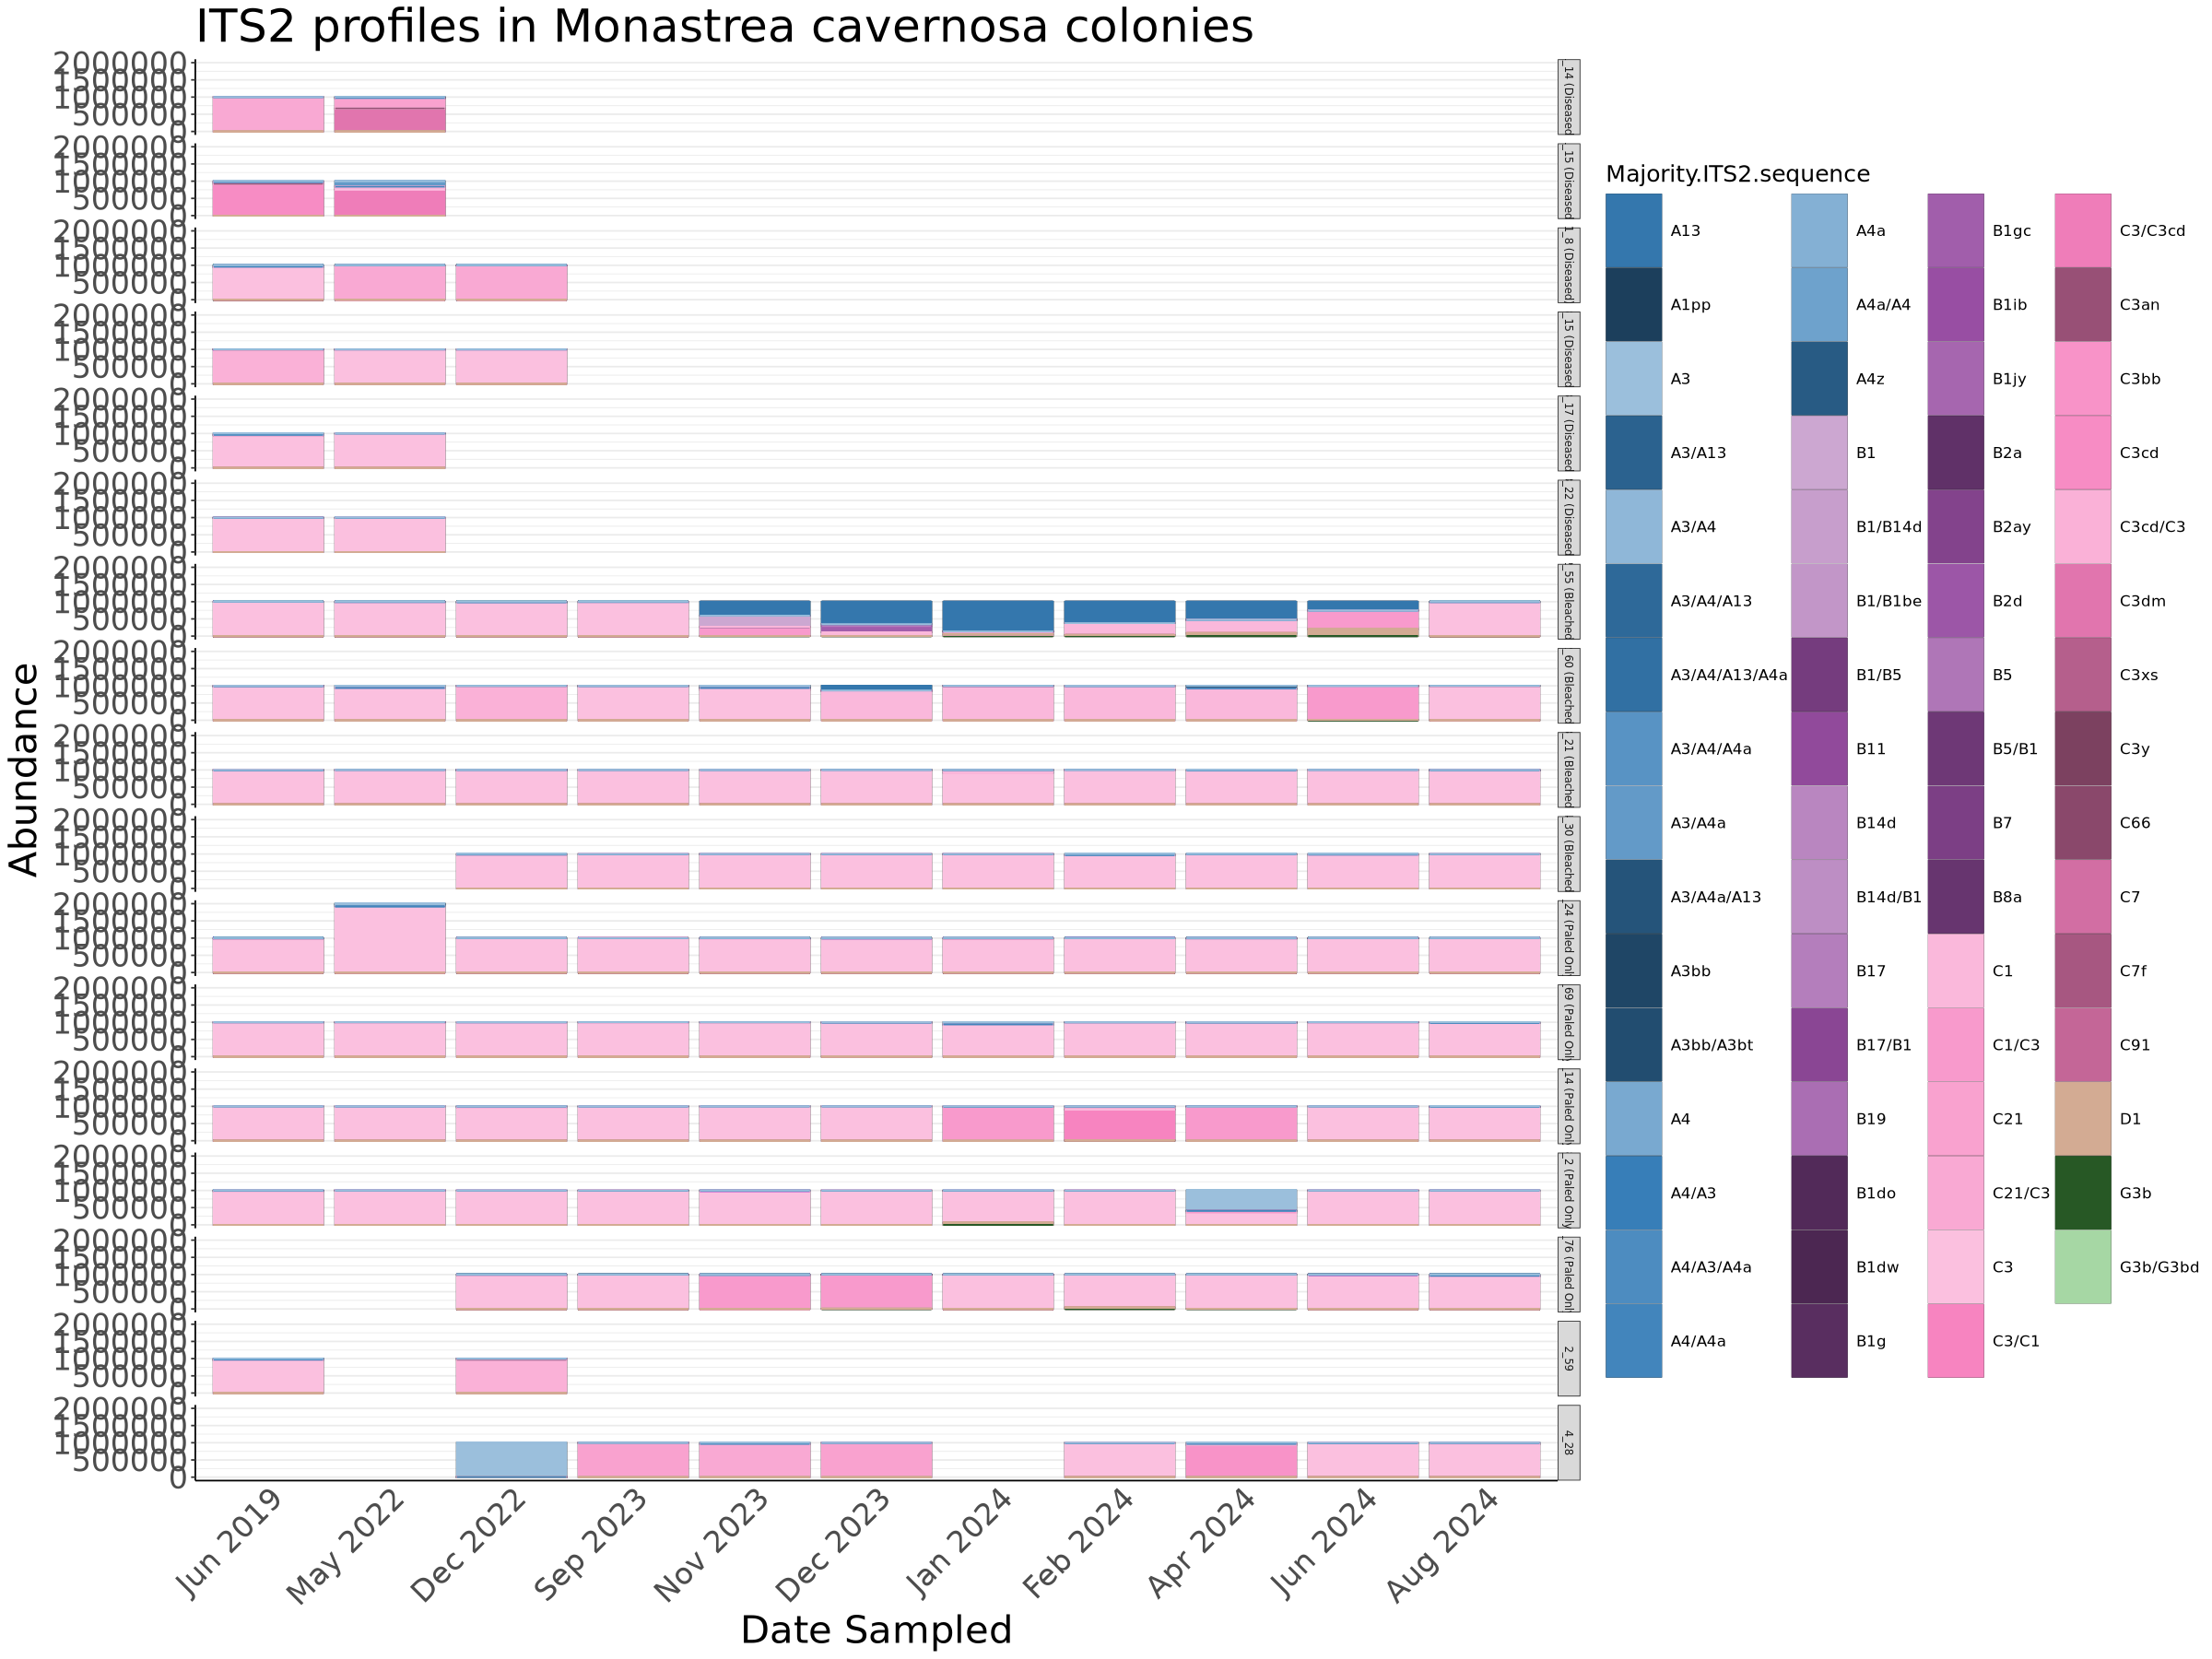

In [40]:
mcav= plot_bar(ps_mcav, x= "Month_year", fill = "Majority.ITS2.sequence") +
facet_wrap(colony_labeled ~., strip.position = "right",  ncol = 1) + # Set desired font size
geom_bar(aes(color = Majority.ITS2.sequence, fill = Majority.ITS2.sequence), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Monastrea cavernosa colonies",
       x = "Date Sampled",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25),
           strip.text = element_text(size = 7) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 20))) 
mcav

## ssid

<Guides[1] ggproto object>

colour : <GuideLegend>

Warning message:
“Removed 406 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 406 rows containing missing values or values outside the scale range
(`geom_bar()`).”


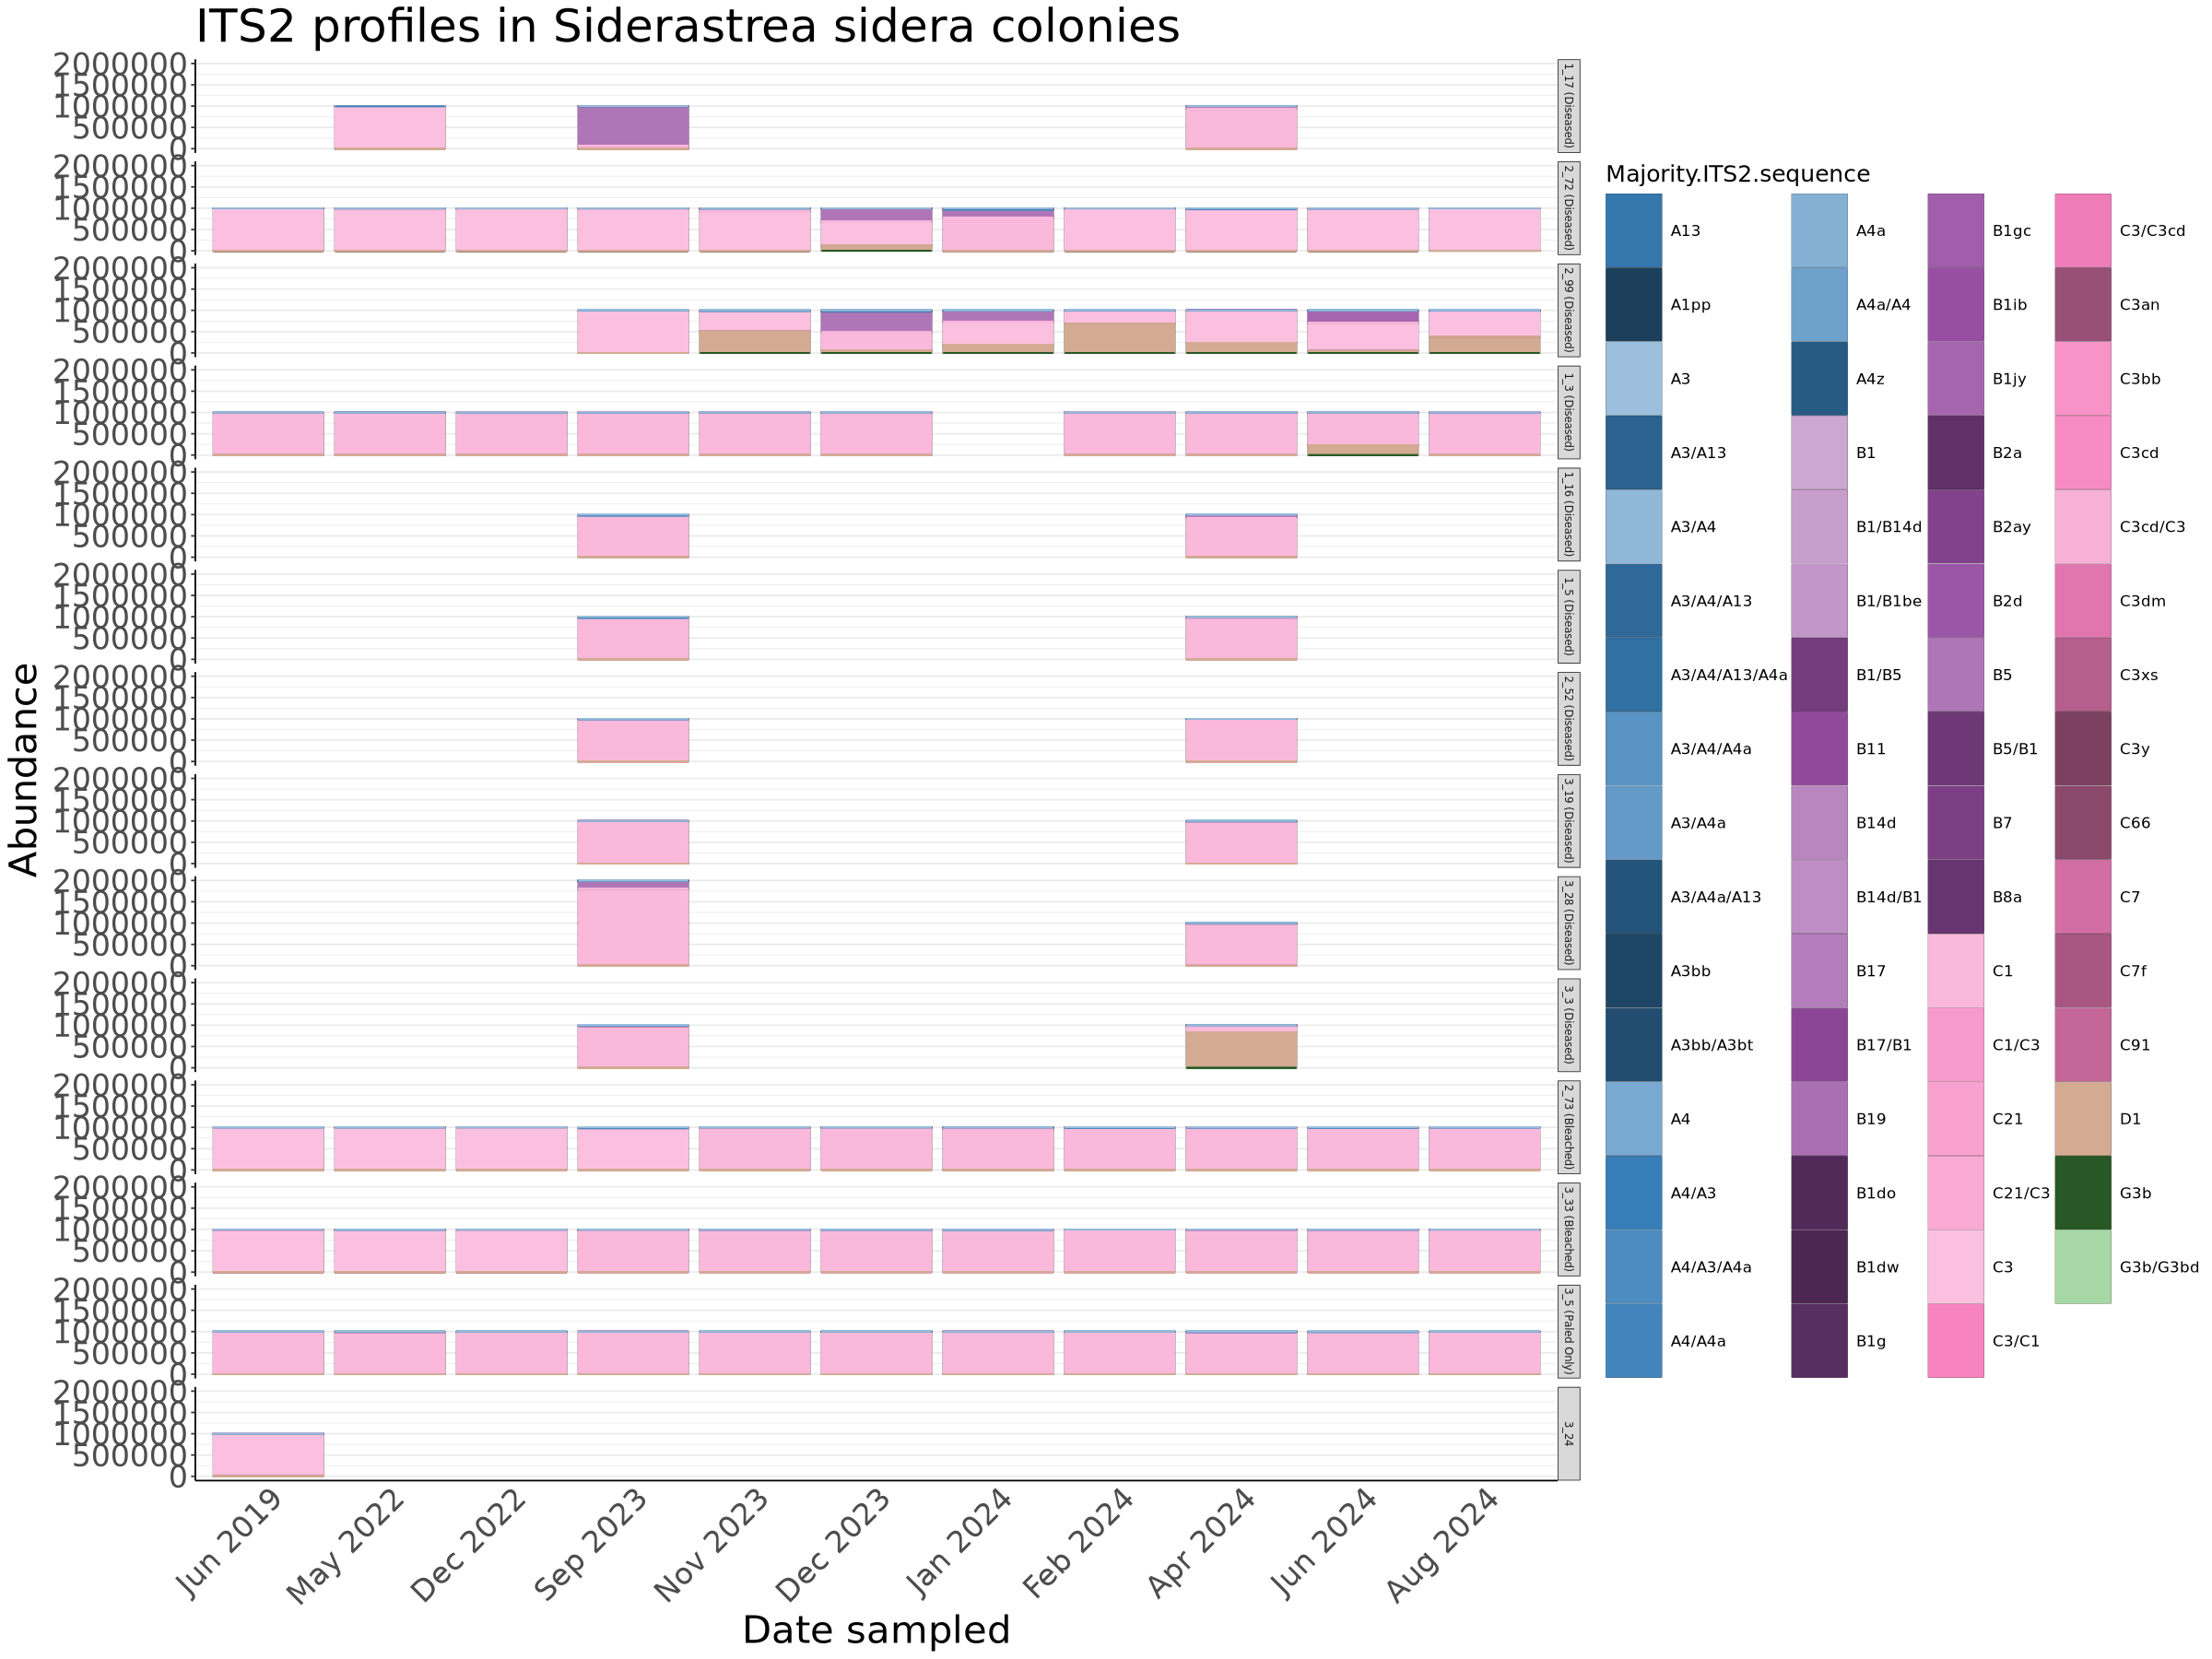

In [41]:

ssid= plot_bar(ps_ssid, x= "Month_year", fill = "Majority.ITS2.sequence") +
facet_wrap(colony_labeled ~., strip.position = "right",  ncol = 1) + # Set desired font size
geom_bar(aes(color = Majority.ITS2.sequence, fill = Majority.ITS2.sequence), 
           stat = "identity", position = "stack") +
  labs(title = "ITS2 profiles in Siderastrea sidera colonies",
       x = "Date sampled",
       y = "Abundance",
       color = "Majority.ITS2.sequence") +
  scale_fill_manual(values = profile_colors, drop = TRUE) +
  scale_color_manual(values = profile_colors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 15),
  legend.text = element_text(size = 10),
legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.7, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25),
           strip.text = element_text(size = 7) #facet size
  )
guides(color = guide_legend(override.aes = list(size = 20))) 
ssid